# YAFS Link Trace Analysis

This notebook analyzes the `sim_trace_link.csv` file, which contains detailed logs of message transmissions over network links in the YAFS simulation.

**Key Metrics Analyzed:**
- **Latency:** The time taken for a message to travel from source to destination.
- **Traffic Volume:** The number of messages and total data size transferred between nodes.
- **Buffer Usage:** The utilization of link buffers during the simulation.
- **Network Topology:** Communication patterns between different nodes (Fog, Cloud, Sensors).

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
We will load the `sim_trace_link.csv` file and examine its structure, data types, and basic statistics.

In [11]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_path = 'resultados/4-custom_proposed_by_felipe-sim_trace_link.csv'
df_link = pd.read_csv(file_path)

# Display the first few rows
display(df_link.head())

# Check data types and missing values
print(df_link.info())

# Basic descriptive statistics
display(df_link.describe())

,id,type,src,dst,srcLabel,dstLabel,app,latency,message,ctime,size,buffer
0,1,LINK,26,25,Application-1-Sensor,Application-1-Router,Application-1,0.657830,M_Req,100.0,1192,0
1,2,LINK,28,27,Application-2-Sensor,Application-2-Router,Application-2,0.904811,M_Req,100.0,1035,1
2,3,LINK,30,29,Application-3-Sensor,Application-3-Router,Application-3,1.083992,M_Req,100.0,960,2
3,4,LINK,32,31,Application-4-Sensor,Application-4-Router,Application-4,1.172673,M_Req,100.0,983,3
4,5,LINK,34,33,Application-5-Sensor,Application-5-Router,Application-5,1.496476,M_Req,100.0,1139,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49022 entries, 0 to 49021
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        49022 non-null  int64  
 1   type      49022 non-null  object 
 2   src       49022 non-null  int64  
 3   dst       49022 non-null  int64  
 4   srcLabel  49022 non-null  object 
 5   dstLabel  49022 non-null  object 
 6   app       49022 non-null  object 
 7   latency   49022 non-null  float64
 8   message   49022 non-null  object 
 9   ctime     49022 non-null  float64
 10  size      49022 non-null  int64  
 11  buffer    49022 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 4.5+ MB
None


,id,src,dst,latency,ctime,size,buffer
count,49022.000000,49022.000000,49022.000000,49022.000000,49022.000000,49022.000000,49022.000000
mean,3823.551059,51.825874,48.328587,5.982901,5021.361137,773.764269,593.642630
std,2282.590003,55.873751,53.786655,5.092381,2856.586442,274.364586,309.346551
min,1.000000,0.000000,0.000000,0.509864,100.000000,405.000000,0.000000
25%,1825.000000,5.000000,4.000000,1.327228,2535.045224,503.000000,327.000000
50%,3762.000000,21.000000,20.000000,5.143015,5014.436450,816.000000,593.000000
75%,5781.000000,95.000000,87.000000,8.767135,7501.082078,1034.000000,862.000000
max,7920.000000,184.000000,184.000000,23.962804,9994.935261,1197.000000,1143.000000


In [12]:
# Load the Application Trace (End-to-End Latency)
# This file contains the full request-response times, including queuing and processing.
app_trace_path = 'resultados/4-custom_proposed_by_felipe-sim_trace.csv'
df_app = pd.read_csv(app_trace_path)

# Calculate End-to-End Latency
df_app['latency'] = df_app['time_reception'] - df_app['time_emit']

# Display basic stats
print("Application End-to-End Latency Stats:")
display(df_app['latency'].describe())

display(df_app.head())

Application End-to-End Latency Stats:


count    14136.000000
mean       209.540849
std        702.182268
min          9.454502
25%         13.993796
50%         16.806764
75%         30.348204
max       7188.427049
Name: latency, dtype: float64

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception,latency
0,34,COMP_M,Application-34,Application-34-Service,M_Req,181,179,92,2,Application-34-Sensor,Fog-1,Application-34-Sensor,0.022638,109.454986,109.477624,100.0,109.454986,9.454986
1,23,COMP_M,Application-23,Application-23-Service,M_Req,148,146,70,2,Application-23-Sensor,Fog-1,Application-23-Sensor,0.018701,109.692204,109.710904,100.0,109.692204,9.692204
2,41,COMP_M,Application-41,Application-41-Service,M_Req,202,200,106,3,Application-41-Sensor,Fog-2,Application-41-Sensor,0.021316,110.253638,110.274954,100.0,110.253638,10.253638
3,16,COMP_M,Application-16,Application-16-Service,M_Req,127,125,56,4,Application-16-Sensor,Fog-3,Application-16-Sensor,0.019507,110.564421,110.583928,100.0,110.564421,10.564421
4,71,COMP_M,Application-71,Application-71-Service,M_Req,292,290,166,1,Application-71-Sensor,Fog-0,Application-71-Sensor,0.023399,111.540209,111.563608,100.0,111.540209,11.540209


## 1.1 Application End-to-End Latency Analysis
**Important:** The `sim_trace_link.csv` analyzed above shows *physical link latency* (Transmission + Propagation), which is often constant in stable networks.
The `sim_trace.csv` loaded here shows **End-to-End Latency**, which includes:
1.  **Queuing Delay:** Time waiting in buffers (congestion).
2.  **Processing Time:** Time spent in the Service module.
3.  **Network Latency:** Sum of all link latencies.

**This metric should show significant variation if the network or nodes are busy.**

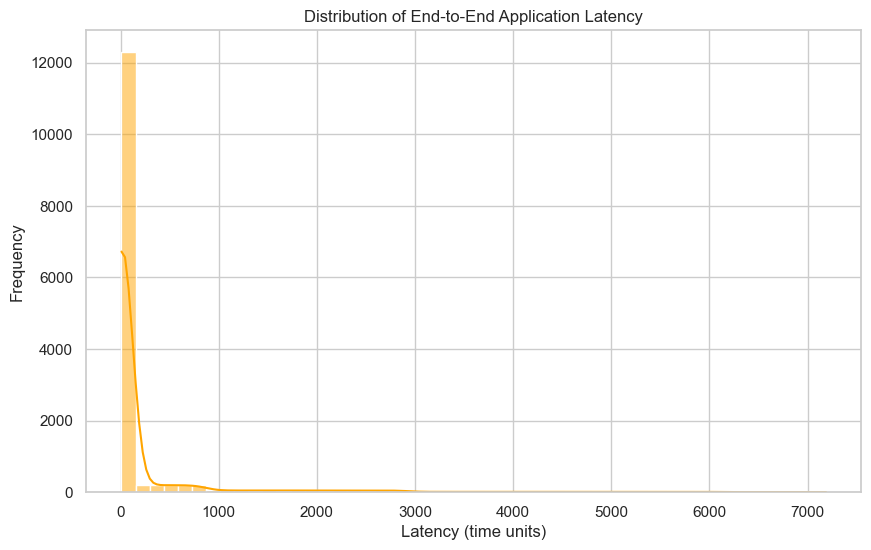

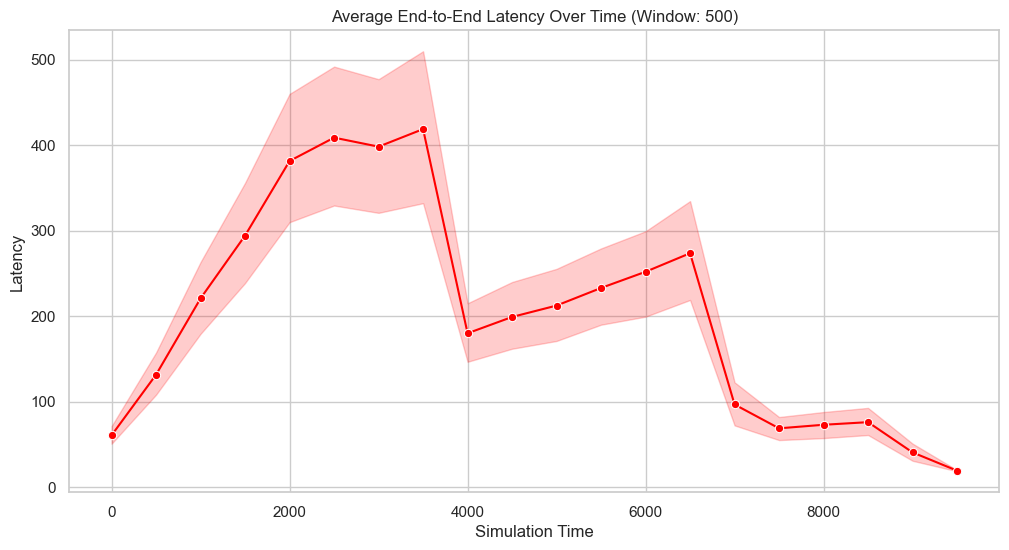

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_78432/714266847.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='app', y='latency', data=df_app_top20, palette='Set3')


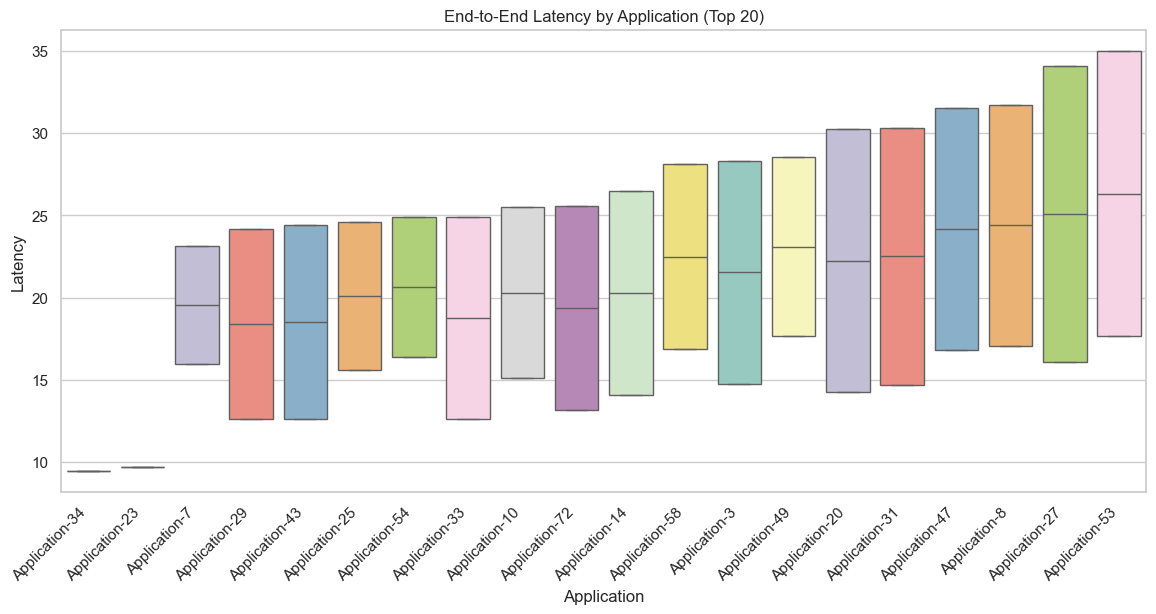

In [13]:
# 1. Distribution of End-to-End Latency
plt.figure(figsize=(10, 6))
sns.histplot(df_app['latency'], kde=True, bins=50, color='orange')
plt.title('Distribution of End-to-End Application Latency')
plt.xlabel('Latency (time units)')
plt.ylabel('Frequency')
plt.show()

# 2. End-to-End Latency Over Time
# Binning time to see trends
window_size_app = 500
df_app['time_window'] = (df_app['time_emit'] // window_size_app) * window_size_app

plt.figure(figsize=(12, 6))
sns.lineplot(x='time_window', y='latency', data=df_app, marker='o', color='red')
plt.title(f'Average End-to-End Latency Over Time (Window: {window_size_app})')
plt.xlabel('Simulation Time')
plt.ylabel('Latency')
plt.grid(True)
plt.show()

# 3. Latency by Application (Top 20)
top_20_apps_e2e = df_app['app'].value_counts().nlargest(20).index
df_app_top20 = df_app[df_app['app'].isin(top_20_apps_e2e)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='app', y='latency', data=df_app_top20, palette='Set3')
plt.title('End-to-End Latency by Application (Top 20)')
plt.xlabel('Application')
plt.ylabel('Latency')
plt.xticks(rotation=45, ha='right')
plt.show()

## 2. Latency Analysis
Latency is a critical metric in network simulations. We will analyze the distribution of latency and compare it across different applications.

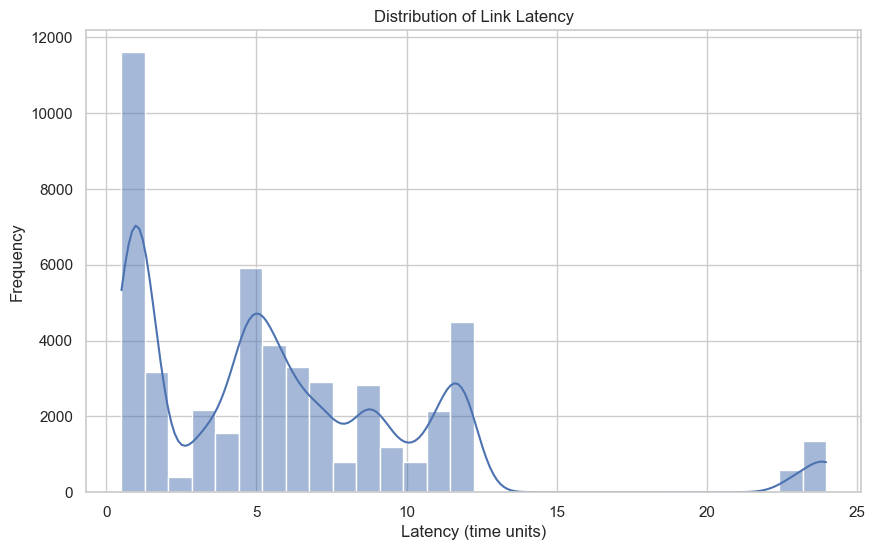

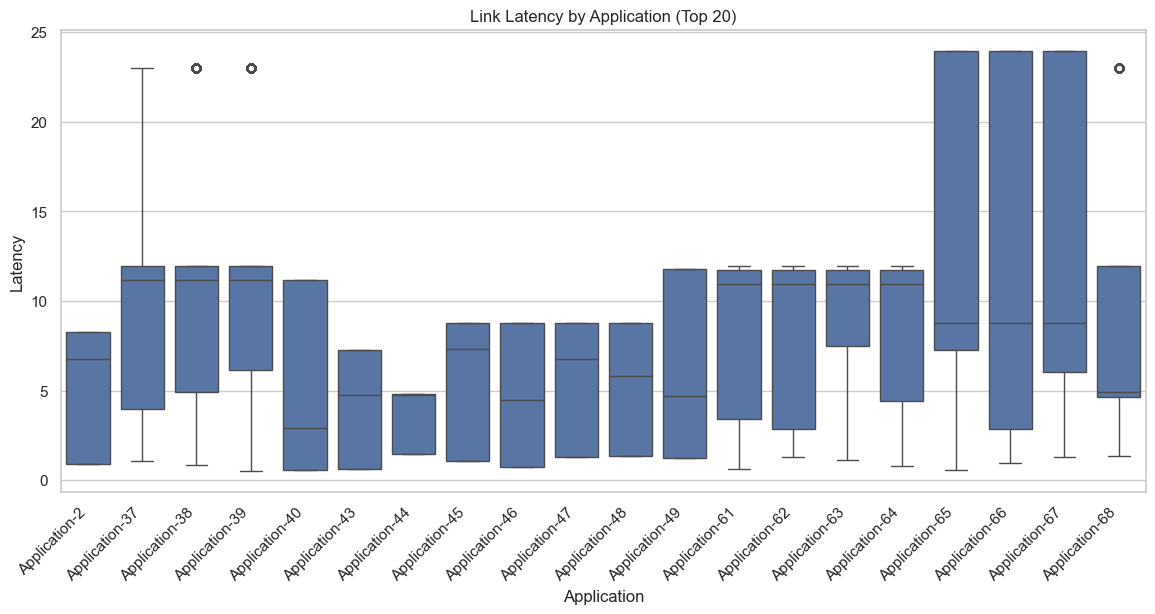

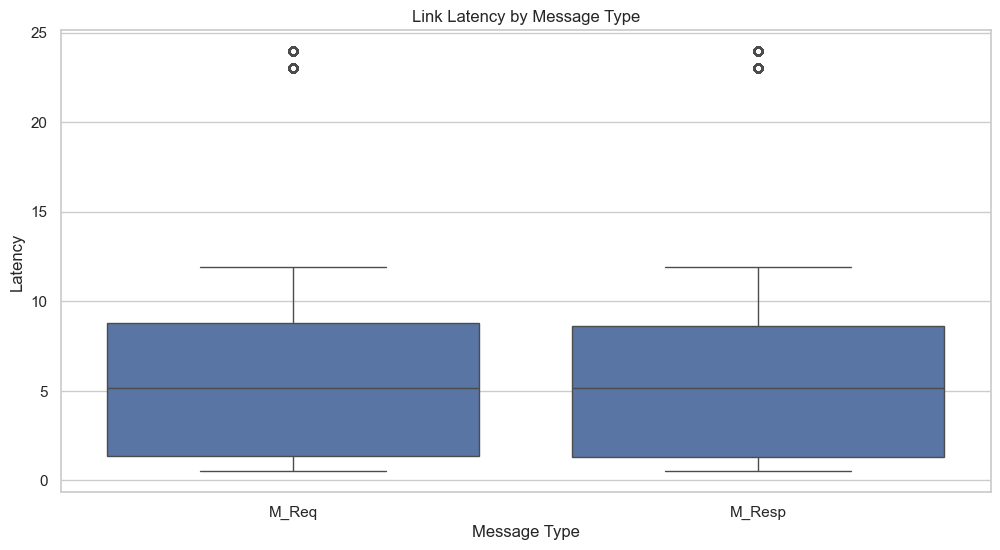

In [14]:
# Latency Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_link['latency'], kde=True, bins=30)
plt.title('Distribution of Link Latency')
plt.xlabel('Latency (time units)')
plt.ylabel('Frequency')
plt.show()

# Latency by Application Boxplot (Top 20)
# Filtering to the top 20 applications to ensure the plot is readable.
top_20_apps = df_link['app'].value_counts().nlargest(20).index
df_top_20 = df_link[df_link['app'].isin(top_20_apps)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='app', y='latency', data=df_top_20)
plt.title('Link Latency by Application (Top 20)')
plt.xlabel('Application')
plt.ylabel('Latency')
plt.xticks(rotation=45, ha='right') # Rotate and align for better readability
plt.show()

# Latency by Message Type
# Since we have different message types (M_Req, M_Resp), it's useful to see their latency
if 'message' in df_link.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='message', y='latency', data=df_link)
    plt.title('Link Latency by Message Type')
    plt.xlabel('Message Type')
    plt.ylabel('Latency')
    plt.show()

### Latency Trends Over Time
Analyzing how latency changes over time can reveal network congestion or the impact of dynamic placement strategies. We bin the simulation time into windows and calculate the average latency for each window.

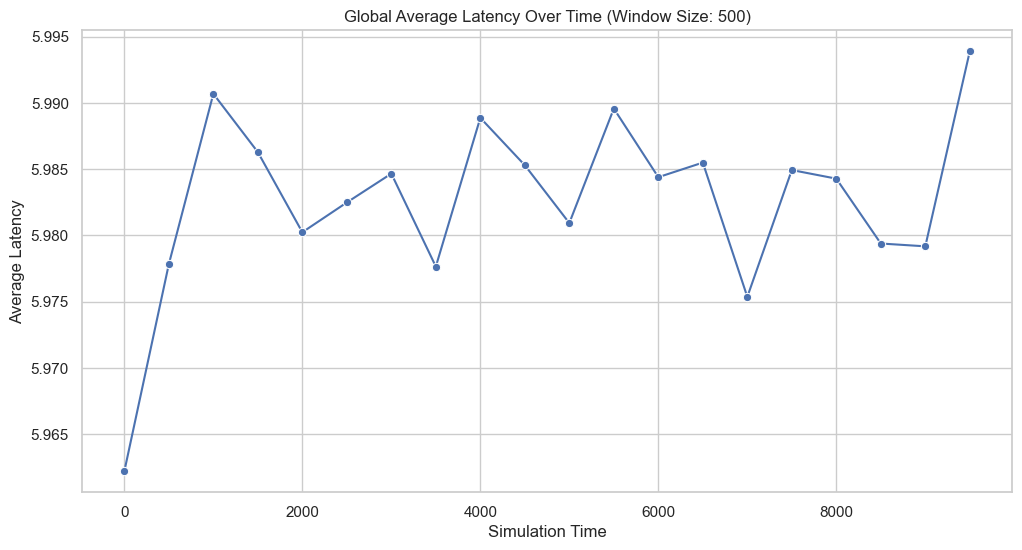

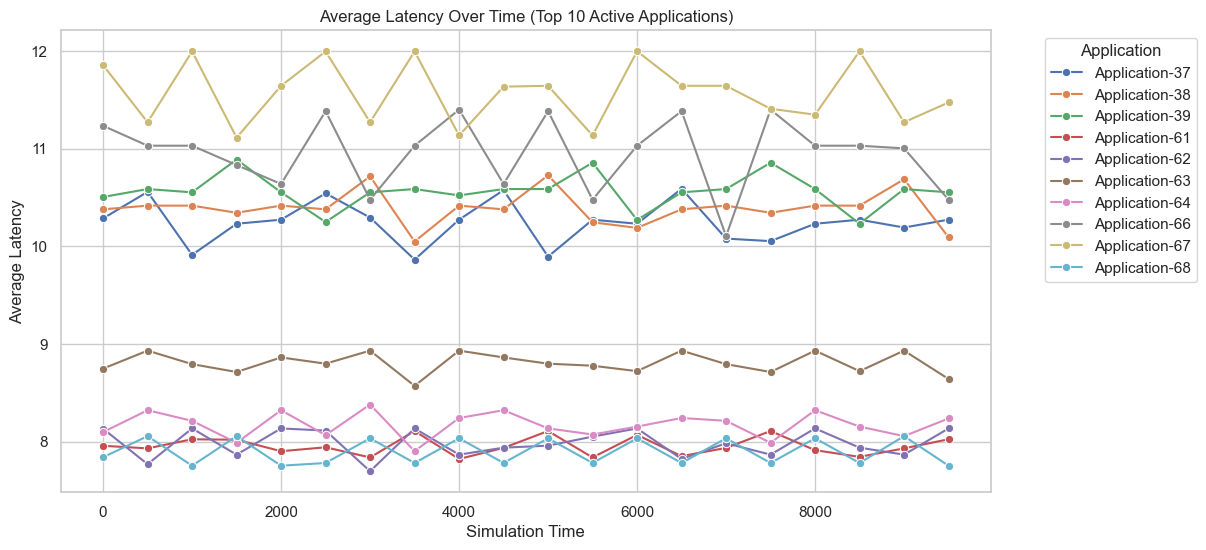

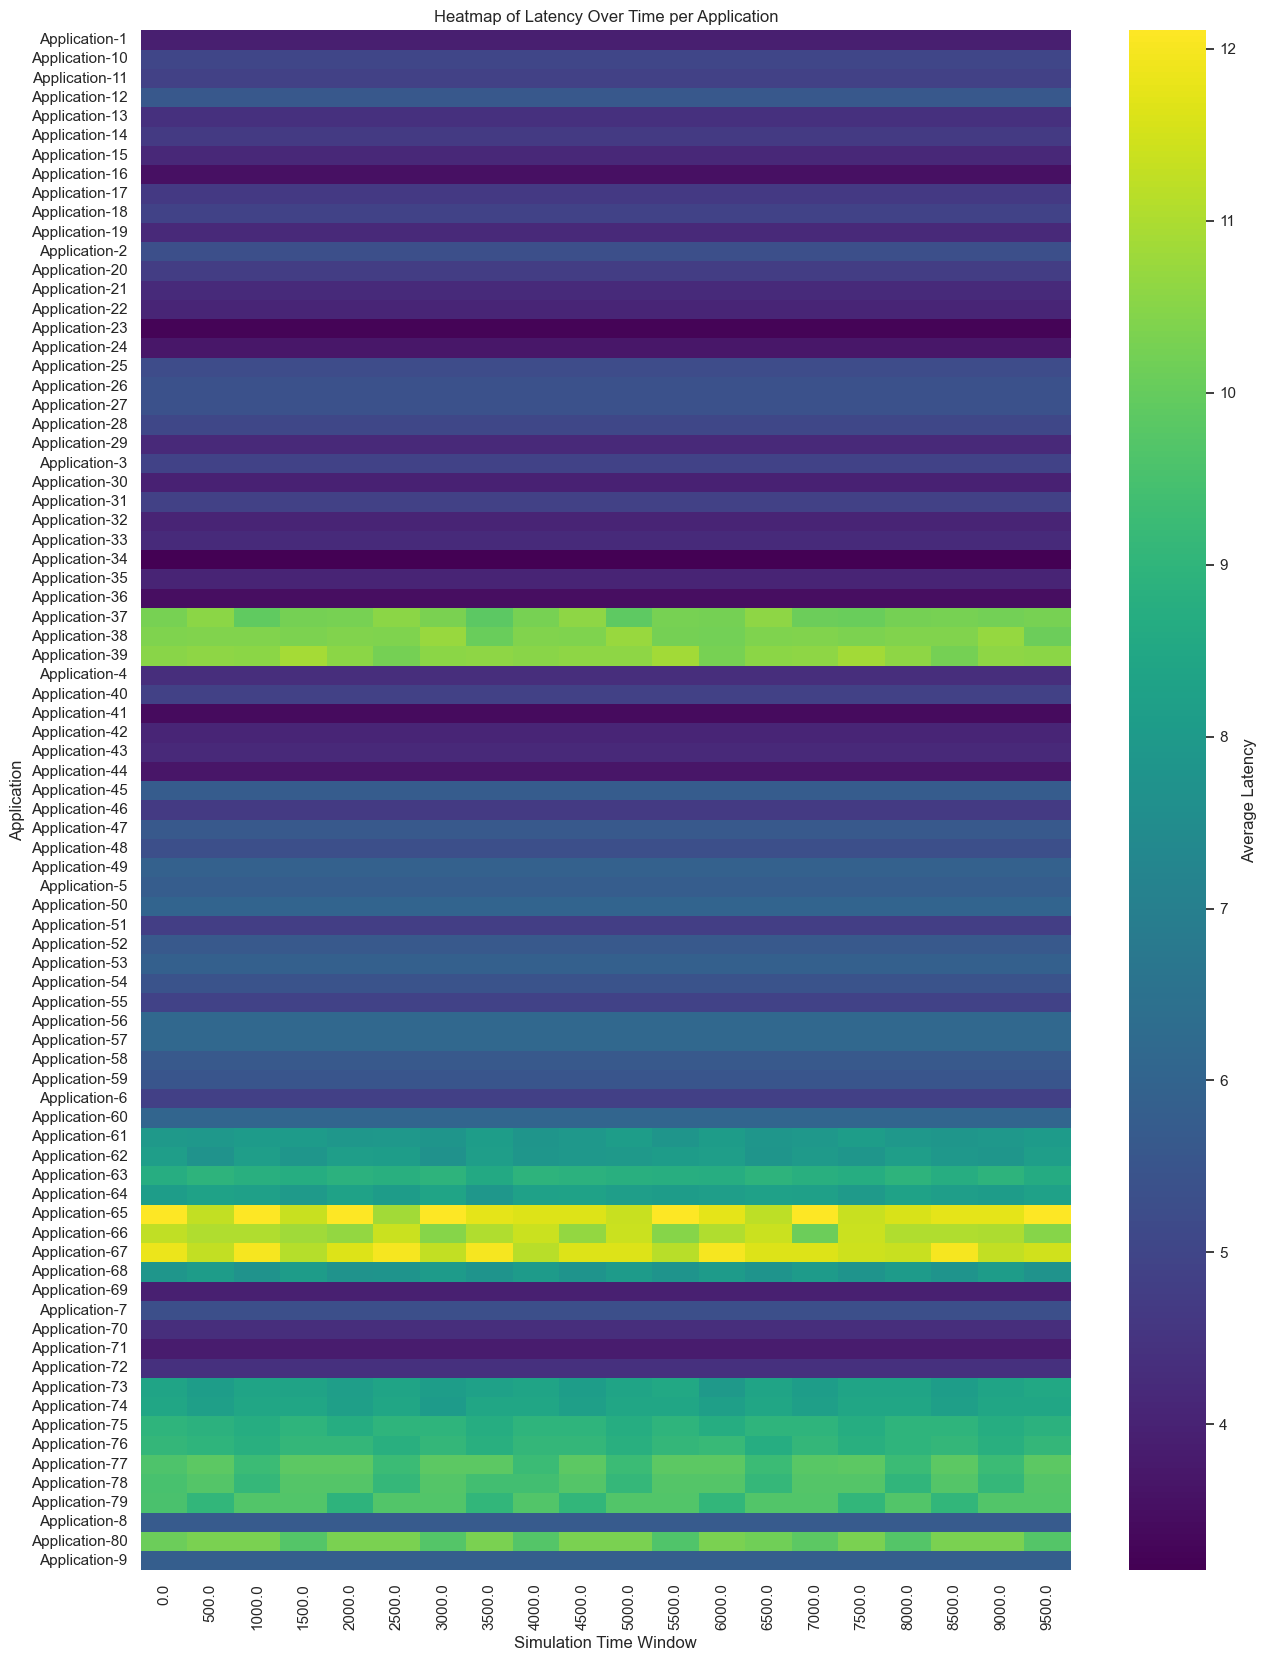

In [15]:
# Define time window size for averaging (e.g., 500 time units)
# You can adjust this value based on your simulation duration
window_size = 500 

# Create a new column for time windows
df_link['time_window'] = (df_link['ctime'] // window_size) * window_size

# Calculate mean latency per time window
latency_trend = df_link.groupby('time_window')['latency'].mean().reset_index()

# Plot Global Average Latency
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_window', y='latency', data=latency_trend, marker='o')
plt.title(f'Global Average Latency Over Time (Window Size: {window_size})')
plt.xlabel('Simulation Time')
plt.ylabel('Average Latency')
plt.grid(True)
plt.show()

# --- Improved Per-Application Analysis ---

# 1. Line Plot for Top 10 Applications (by message count)
# Plotting all 80+ applications results in an unreadable plot and legend.
top_apps = df_link['app'].value_counts().nlargest(10).index
df_top_apps = df_link[df_link['app'].isin(top_apps)]

plt.figure(figsize=(12, 6))
latency_trend_app = df_top_apps.groupby(['time_window', 'app'])['latency'].mean().reset_index()
sns.lineplot(x='time_window', y='latency', hue='app', data=latency_trend_app, marker='o')
plt.title(f'Average Latency Over Time (Top 10 Active Applications)')
plt.xlabel('Simulation Time')
plt.ylabel('Average Latency')
plt.legend(title='Application', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# 2. Heatmap for ALL Applications
# A heatmap is better for visualizing latency trends across many applications simultaneously.
latency_pivot = df_link.pivot_table(index='app', columns='time_window', values='latency', aggfunc='mean')

plt.figure(figsize=(15, 20)) # Taller figure for many apps
sns.heatmap(latency_pivot, cmap='viridis', annot=False, cbar_kws={'label': 'Average Latency'})
plt.title('Heatmap of Latency Over Time per Application')
plt.xlabel('Simulation Time Window')
plt.ylabel('Application')
plt.show()

## 3. Traffic Analysis
We will analyze the volume of traffic generated by each application and visualize the communication patterns between nodes using a heatmap.

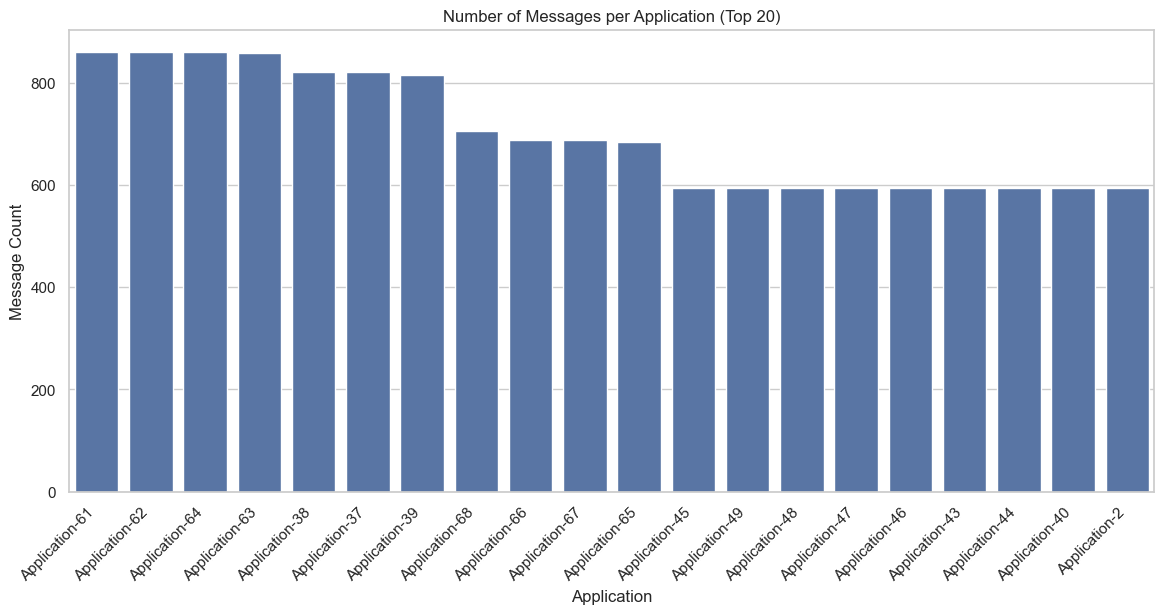

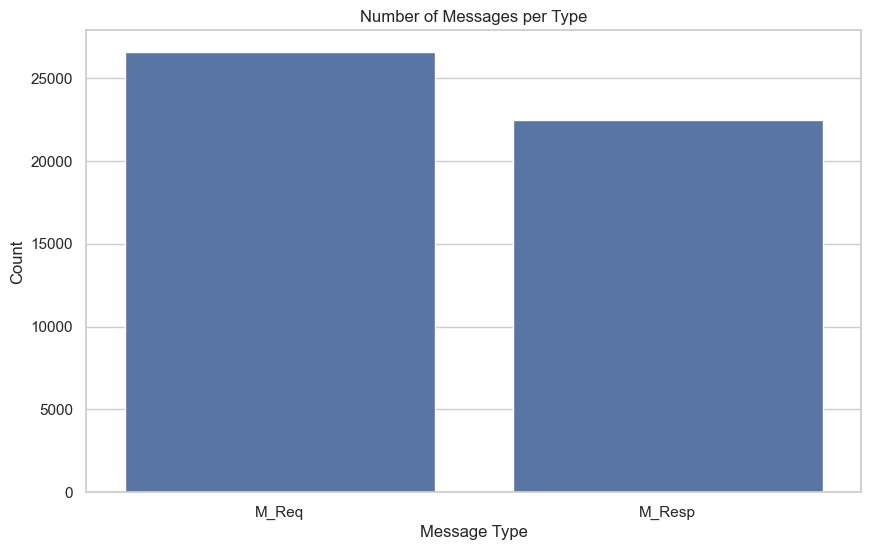

Heatmap is too large ((185, 185)), filtering to top 30 active nodes.


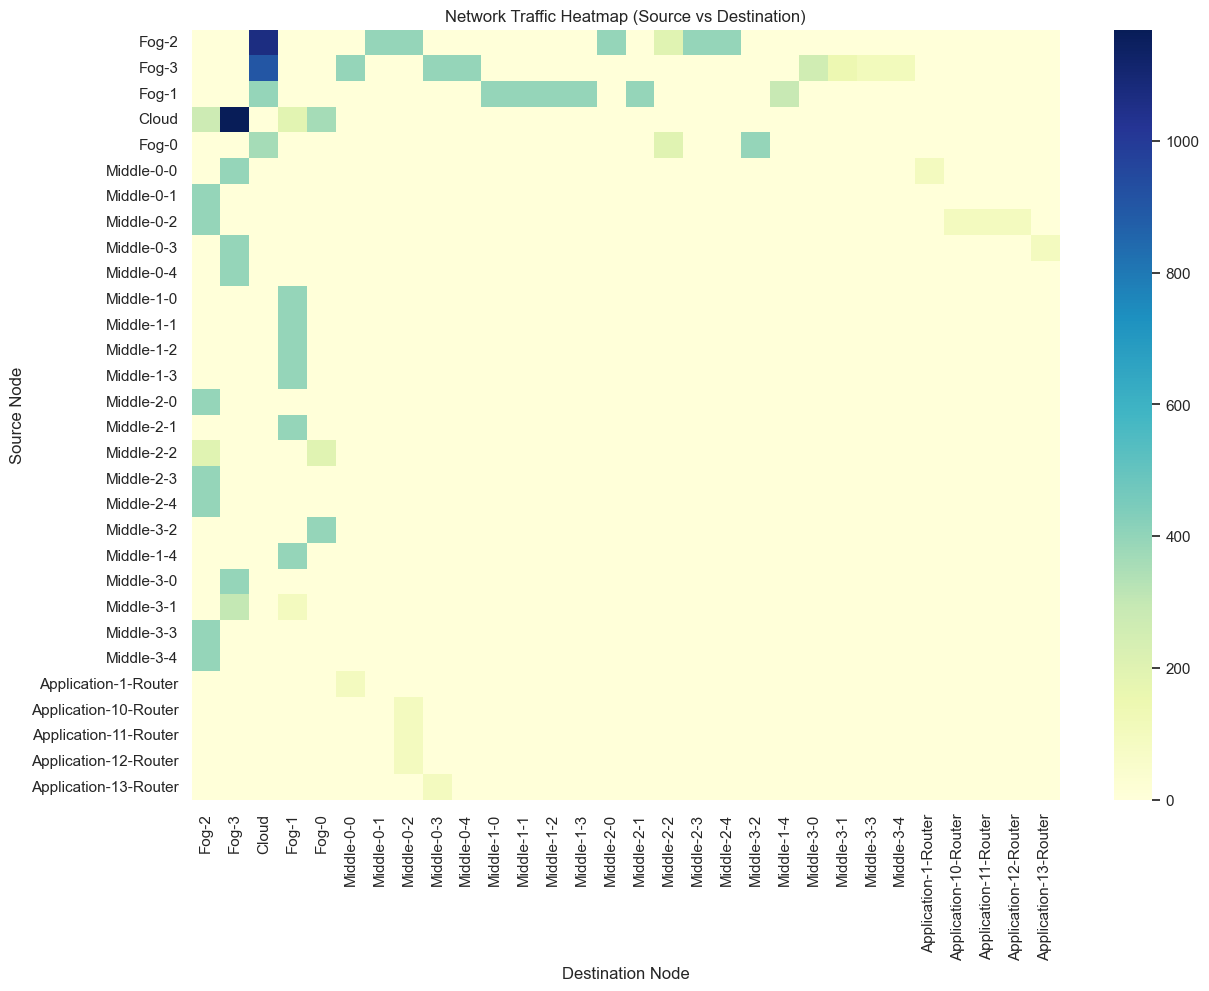

In [16]:
# Message Count per Application (Top 20)
plt.figure(figsize=(14, 6))
# Get top 20 apps
top_20_apps_count = df_link['app'].value_counts().nlargest(20)
sns.barplot(x=top_20_apps_count.index, y=top_20_apps_count.values)
plt.title('Number of Messages per Application (Top 20)')
plt.xlabel('Application')
plt.ylabel('Message Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Message Count per Message Type
if 'message' in df_link.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='message', data=df_link)
    plt.title('Number of Messages per Type')
    plt.xlabel('Message Type')
    plt.ylabel('Count')
    plt.show()

# Communication Heatmap (Source vs Destination)
# Create a pivot table counting occurrences
# We might need to filter this too if there are too many nodes, but let's try full first or filter by top interactions
heatmap_data = pd.crosstab(df_link['srcLabel'], df_link['dstLabel'])

# Check size of heatmap
if heatmap_data.shape[0] > 50 or heatmap_data.shape[1] > 50:
    print(f"Heatmap is too large ({heatmap_data.shape}), filtering to top 30 active nodes.")
    # Filter to top 30 active nodes (by sum of outgoing/incoming)
    top_src = heatmap_data.sum(axis=1).nlargest(30).index
    top_dst = heatmap_data.sum(axis=0).nlargest(30).index
    heatmap_data = heatmap_data.loc[top_src, top_dst]

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=False, fmt='d', cmap='YlGnBu') # annot=False for cleaner view if dense
plt.title('Network Traffic Heatmap (Source vs Destination)')
plt.xlabel('Destination Node')
plt.ylabel('Source Node')
plt.show()

## 4. Buffer Usage Analysis
Understanding buffer usage is crucial for identifying potential congestion points. We will look at the distribution of buffer sizes and how buffer usage changes over time.

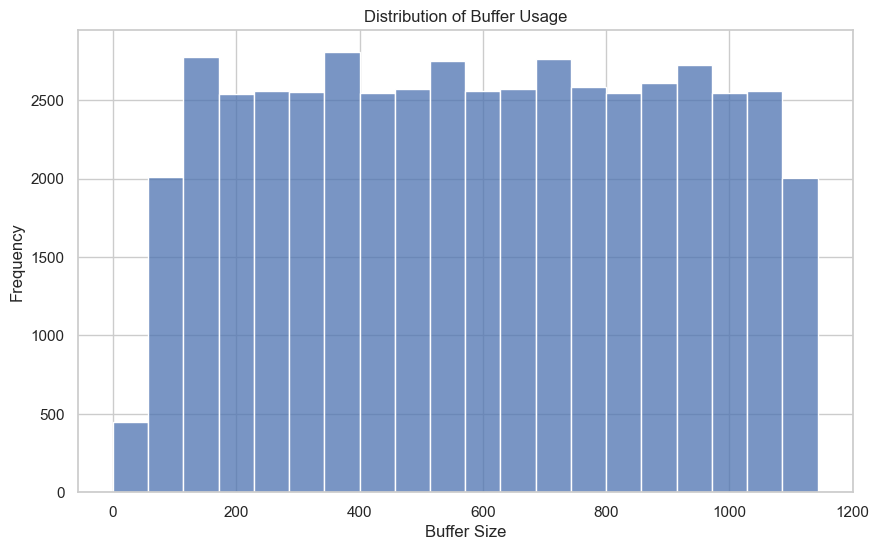

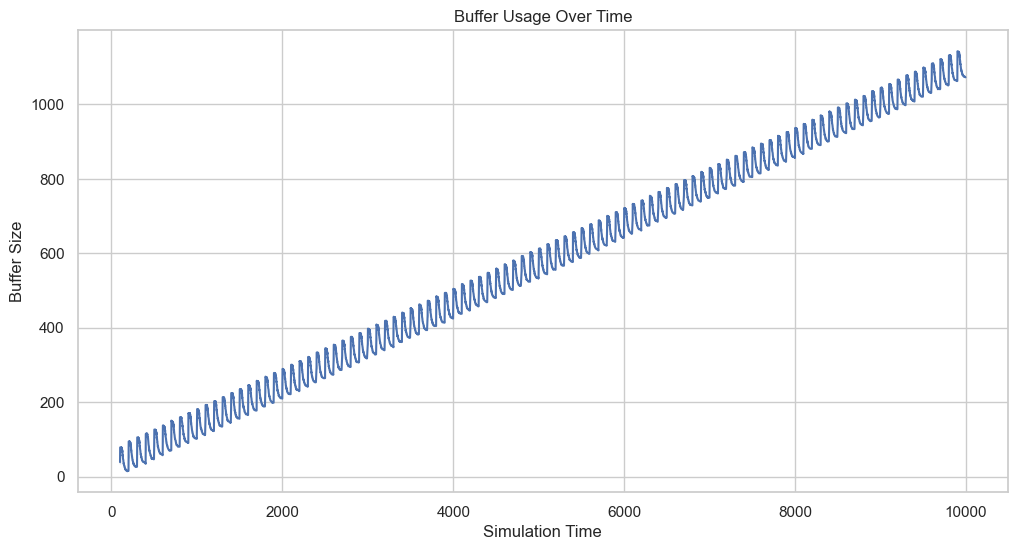

In [17]:
# Buffer Size Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_link['buffer'], bins=20, kde=False)
plt.title('Distribution of Buffer Usage')
plt.xlabel('Buffer Size')
plt.ylabel('Frequency')
plt.show()

# Buffer Usage Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='ctime', y='buffer', data=df_link)
plt.title('Buffer Usage Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Buffer Size')
plt.show()

## 5. Throughput Analysis
We will visualize the cumulative data transferred over the network to understand the throughput of the system.

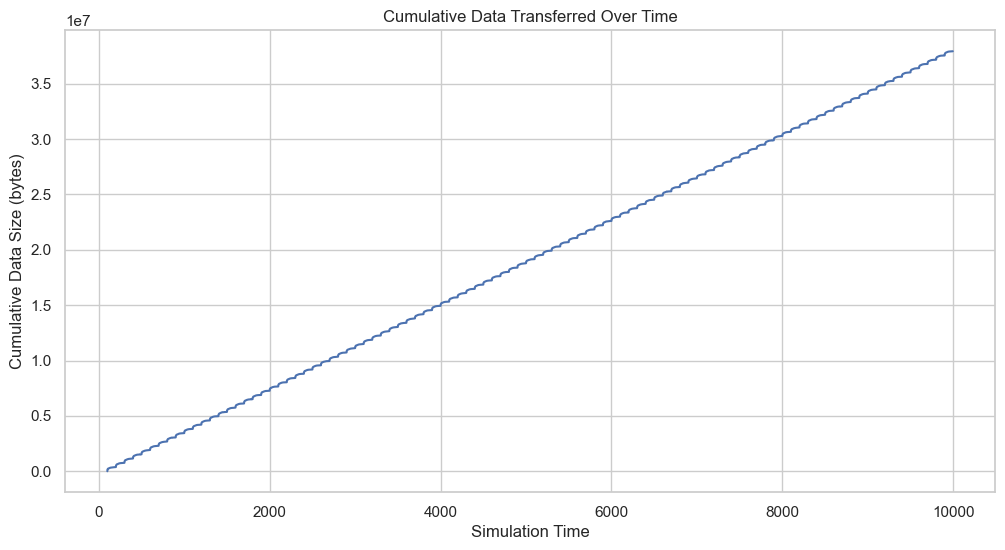

In [18]:
# Sort by time
df_link_sorted = df_link.sort_values('ctime')

# Calculate cumulative size
df_link_sorted['cumulative_size'] = df_link_sorted['size'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(df_link_sorted['ctime'], df_link_sorted['cumulative_size'])
plt.title('Cumulative Data Transferred Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Cumulative Data Size (bytes)')
plt.show()

## 6. Conclusion
This notebook provides a detailed analysis of the network link traces.
- **Latency**: Check if any application experiences abnormal delays.
- **Traffic**: Identify the most communicative nodes using the heatmap.
- **Buffer**: Ensure buffers are not consistently full, which would indicate congestion.
- **Throughput**: Observe the rate of data transfer over the simulation period.